**Goal**: To construct a Causal Graph for the AMIB dataset by integrating feature selection and structure learning methods. 
We used the Minimum Redundancy Maximum Relevance (mRMR) algorithm to identify the most informative affective variables related to the outcome variable “satisfied”, and then employ the K2 structure learning algorithm to infer directional relationships among these emotions.

**Install Libraries**

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

**1. Load AMIB data**

In [2]:
# ---------------------------------------------------------------
# STEP 1 - Load AMIB daily data
# ---------------------------------------------------------------

df = pd.read_csv("AMIB_daily.csv")
print(df.head())

    id  day  slphrs  slpwell  weath  lteq   pss   se  ssgs_shame  ssgs_guilt  \
0  101    0     6.0      1.0    1.0  10.0  2.50  2.0         1.4         2.2   
1  101    1     2.0      1.0    2.0  10.0  2.75  3.0         1.4         1.4   
2  101    2     9.0      3.0    3.0  10.0  3.50  4.0         1.0         1.0   
3  101    3     7.5      3.0    2.0   9.0  3.00  4.0         1.0         1.0   
4  101    4     8.0      4.0    1.0  18.0  2.75  3.0         1.0         1.0   

   ...  pfi_hubr  evalday  posaff  negaff  affbalance  temp   hum  wind  \
0  ...  2.000000      1.0     3.9     3.0         0.9  28.0  0.79  11.0   
1  ...  1.142857      0.0     3.8     2.3         1.5  20.8  0.62   3.6   
2  ...  1.000000      1.0     5.1     1.0         4.1  29.1  0.51   1.9   
3  ...  1.000000      1.0     5.6     1.3         4.3  30.2  0.58   2.7   
4  ...  1.000000      1.0     4.3     1.1         3.2  22.7  0.55   2.4   

     bar  prec  
0  29.40  0.20  
1  30.17  0.00  
2  30.35  0.02  


**2. Describe the variables of interest in the AMIB data**

In [3]:
# ---------------------------------------------------------------
# STEP 2 - Select positive affect variables and drop missing rows
# ---------------------------------------------------------------

positive_affect_vars = [
    "enthusiastic", "calm", "happy", "peaceful", "satisfied",
    "proud", "relaxed", "excited", "content", "relieved"
]

# Keep only those columns
data = df[positive_affect_vars].copy()

# Drop rows with any missing values in these columns
data = data.dropna()

print(f"Remaining rows after dropping missing values: {len(data)}")
print("\nFirst 5 rows of cleaned affect data (still continuous 1-7 scale):")
print(data.head())


Remaining rows after dropping missing values: 1431

First 5 rows of cleaned affect data (still continuous 1-7 scale):
   enthusiastic  calm  happy  peaceful  satisfied  proud  relaxed  excited  \
0           4.0   5.0    4.0       5.0        3.0    3.0      5.0      3.0   
1           2.0   6.0    6.0       6.0        5.0    2.0      5.0      2.0   
2           5.0   5.0    6.0       6.0        6.0    2.0      7.0      5.0   
3           6.0   6.0    6.0       6.0        6.0    7.0      6.0      6.0   
4           5.0   5.0    6.0       6.0        4.0    1.0      5.0      5.0   

   content  relieved  
0      4.0       3.0  
1      3.0       2.0  
2      6.0       1.0  
3      5.0       1.0  
4      5.0       1.0  


**3. Discretize the data**

In [4]:
# ---------------------------------------------------------------
# STEP 3 - Discretize continuous emotion scores into 3 bins
# ---------------------------------------------------------------

disc_data = data.copy()

for col in disc_data.columns:
    # Only discretize numeric columns
    if disc_data[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        disc_data[col] = pd.cut(
            disc_data[col],
            bins=3,              # Create 3 bins: Low (0), Medium (1), High (2)
            labels=False,
            duplicates='drop'
        )

print(f"Remaining rows after dropping missing values: {len(disc_data)}")

print("\nDiscretized data (first 5 rows):")
print(disc_data.head())


Remaining rows after dropping missing values: 1431

Discretized data (first 5 rows):
   enthusiastic  calm  happy  peaceful  satisfied  proud  relaxed  excited  \
0             1     1      1         1          0      0        1        0   
1             0     2      2         2          1      0        1        0   
2             1     1      2         2          2      0        2        1   
3             2     2      2         2          2      2        2        2   
4             1     1      2         2          1      0        1        1   

   content  relieved  
0        1         0  
1        0         0  
2        2         0  
3        1         0  
4        1         0  


**4. Feature Selection using Minimum Redundancy Maximum Relevance (mRmR)**

In [9]:
# ---------------------------------------------------------------
# STEP 4A -  mRMR
# ---------------------------------------------------------------

def mutual_info_feature(x_vals, y_vals):
    """
    Compute mutual information between two discrete variables.
    Higher MI = x tells us more about y.
    """
    return mutual_info_classif(
        x_vals.reshape(-1, 1),
        y_vals,
        discrete_features=True
    )[0]

def average_redundancy(feature, selected_list, table):
    """
    Compute how redundant `feature` is with the features we've already selected.
    Redundancy = average mutual information between this feature and each selected one.
    Lower is better.
    """
    if len(selected_list) == 0:
        return 0.0

    vals_f = table[feature].values
    total = 0.0
    for already in selected_list:
        vals_sel = table[already].values
        total += mutual_info_feature(vals_f, vals_sel)
    return total / len(selected_list)


# ---------------------------------------------------------------
# STEP 4B - Run mRMR to rank and select key affect variables
# ---------------------------------------------------------------

target_variable = "satisfied"    # Insert "satisfied" #
if target_variable not in disc_data.columns:
    # In case 'satisfied' isn't there for some reason, fall back gracefully
    target_variable = disc_data.columns[0]
    print(f"Warning: using {target_variable} as target")

# candidate predictors = all other affect variables except the target
features = [c for c in disc_data.columns if c != target_variable]

# y is the target (satisfied levels)
y = disc_data[target_variable].values

selected_features = []
remaining = features.copy()

print("="*60)
print(f"mRMR FEATURE SELECTION (Target: {target_variable})")
print("="*60)

# 1. Pick the first feature with the highest mutual information with the target
relevances = {}
for feat in remaining:
    relevances[feat] = mutual_info_feature(disc_data[feat].values, y)

first_best = max(relevances, key=relevances.get)
selected_features.append(first_best)
remaining.remove(first_best)

print(f"1. Selected {first_best:15s} (Relevance={relevances[first_best]:.4f})")

# 2. Iteratively pick more features
# Score = Relevance to target - Redundancy with already-selected features
max_features = 10  # cap on how many we keep (you can adjust)

while len(selected_features) < min(max_features, len(features)):
    mrmr_scores = {}
    for feat in remaining:
        rel = mutual_info_feature(disc_data[feat].values, y)
        red = average_redundancy(feat, selected_features, disc_data)
        mrmr_scores[feat] = rel - red

    # choose the feature with the best (relevance - redundancy)
    best_next = max(mrmr_scores, key=mrmr_scores.get)
    selected_features.append(best_next)
    remaining.remove(best_next)

    print(f"{len(selected_features)}. Selected {best_next:15s} (mRMR={mrmr_scores[best_next]:.4f})")

print("\n✓ Selected features (without the target):")
print(selected_features)

# OPTIONAL: add the target variable ('satisfied') back so it can appear in the network
if target_variable not in selected_features:
    selected_features.append(target_variable)
    print(f"{len(selected_features)}. Added {target_variable:15s} (target variable)")

print("\nFINAL FEATURE SET FOR CAUSAL GRAPH:")
print(selected_features)

# We'll use just these columns in the next step (K2 structure learning)
learn_table = disc_data[selected_features].copy()


mRMR FEATURE SELECTION (Target: satisfied)
1. Selected content         (Relevance=0.2394)
2. Selected enthusiastic    (mRMR=0.0324)
3. Selected proud           (mRMR=0.0179)
4. Selected calm            (mRMR=0.0181)
5. Selected happy           (mRMR=0.0359)
6. Selected relieved        (mRMR=0.0097)
7. Selected excited         (mRMR=0.0240)
8. Selected relaxed         (mRMR=0.0129)
9. Selected peaceful        (mRMR=-0.0220)

✓ Selected features (without the target):
['content', 'enthusiastic', 'proud', 'calm', 'happy', 'relieved', 'excited', 'relaxed', 'peaceful']
10. Added satisfied       (target variable)

FINAL FEATURE SET FOR CAUSAL GRAPH:
['content', 'enthusiastic', 'proud', 'calm', 'happy', 'relieved', 'excited', 'relaxed', 'peaceful', 'satisfied']


**5. K2 Scores to learn Causal directions**

In [10]:
# ---------------------------------------------------------------
# STEP 5 - Learn causal structure using K2 algorithm
# ---------------------------------------------------------------

# --- Step 5A: Define K2 scoring function ---
def k2_score_node(child, parents, table):
    """
    Compute the K2 score for a given child node with a set of parents.
    Higher scores indicate better parent sets.
    """
    child_vals = table[child].values.astype(int)

    # Case 1: no parents
    if len(parents) == 0:
        counts = np.bincount(child_vals)
        n = len(child_vals)
        r = len(counts)
        score = math.log(math.factorial(r - 1))
        for c in counts:
            if c > 0:
                score += math.log(math.factorial(int(c)))
        score -= math.log(math.factorial(n + r - 1))
        return score

    # Case 2: with parents
    parent_mat = table[parents].values
    parent_configs = {}

    # Group child values by each unique parent configuration
    for i, config in enumerate(parent_mat):
        key = tuple(config)
        parent_configs.setdefault(key, [])
        parent_configs[key].append(int(child_vals[i]))

    score = 0.0
    r = len(np.unique(child_vals))

    for vals in parent_configs.values():
        n_ij = len(vals)
        counts = np.bincount(vals)
        score += math.log(math.factorial(r - 1))
        for c in counts:
            if c > 0:
                score += math.log(math.factorial(int(c)))
        score -= math.log(math.factorial(n_ij + r - 1))

    return score

# --- Step 5B: Learn K2 structure ---
def learn_k2_structure(nodes_in_order, table, max_parents=3):
    """
    Greedy K2 algorithm:
    - Uses nodes_in_order as variable order
    - For each node, adds parents (from earlier nodes) only if score improves
    """
    structure = {node: [] for node in nodes_in_order}

    print("\n" + "="*60)
    print(f"K2 STRUCTURE LEARNING (Max Parents: {max_parents})")
    print("="*60 + "\n")

    for i, node in enumerate(nodes_in_order):
        candidates = nodes_in_order[:i]  # only earlier nodes can be parents
        if not candidates:
            continue

        chosen_parents = []
        best_score = k2_score_node(node, chosen_parents, table)

        improved = True
        while improved and len(chosen_parents) < max_parents and len(candidates) > 0:
            improved = False
            best_parent = None
            best_new_score = best_score

            for cand in candidates:
                if cand in chosen_parents:
                    continue
                trial_parents = chosen_parents + [cand]
                trial_score = k2_score_node(node, trial_parents, table)

                if trial_score > best_new_score:
                    best_new_score = trial_score
                    best_parent = cand

            if best_parent is not None:
                chosen_parents.append(best_parent)
                best_score = best_new_score
                improved = True
                structure[node] = chosen_parents.copy()

        if chosen_parents:
            print(f"{node:15s} <- {chosen_parents}")

    roots = [n for n, ps in structure.items() if len(ps) == 0]
    print("\nNodes with no parents (roots):", roots)

    return structure

# --- Step 5C: Run the structure learner ---
max_parents = 3  # limit complexity
nodes_order = selected_features  # use mRMR order as causal order
structure = learn_k2_structure(nodes_order, learn_table, max_parents=max_parents)

print("\nLearned structure (child → parents):")
print(structure)



K2 STRUCTURE LEARNING (Max Parents: 3)

enthusiastic    <- ['content']
proud           <- ['enthusiastic', 'content']
calm            <- ['content', 'enthusiastic']
happy           <- ['enthusiastic', 'content']
relieved        <- ['proud', 'content']
excited         <- ['enthusiastic', 'content', 'happy']
relaxed         <- ['calm', 'content']
peaceful        <- ['calm', 'happy', 'relaxed']
satisfied       <- ['content', 'happy', 'proud']

Nodes with no parents (roots): ['content']

Learned structure (child → parents):
{'content': [], 'enthusiastic': ['content'], 'proud': ['enthusiastic', 'content'], 'calm': ['content', 'enthusiastic'], 'happy': ['enthusiastic', 'content'], 'relieved': ['proud', 'content'], 'excited': ['enthusiastic', 'content', 'happy'], 'relaxed': ['calm', 'content'], 'peaceful': ['calm', 'happy', 'relaxed'], 'satisfied': ['content', 'happy', 'proud']}


**6. Model Evaluation**

In [11]:
# ---------------------------------------------------------------
# STEP 6 - Evaluate the learned causal graph
# ---------------------------------------------------------------

# 6a. Build a NetworkX directed graph from the learned structure
G = nx.DiGraph()
for child, parents in structure.items():
    G.add_node(child)
    for p in parents:
        G.add_edge(p, child)

print("Graph summary:")
print(f"  Nodes:          {len(G.nodes())}")
print(f"  Directed edges: {len(G.edges())}")


# 6b. Compute log-likelihood of the data under the learned structure
def compute_log_likelihood(structure, table):
    """
    For each node, compute P(node | parents) from the data (empirical CPT),
    then sum log probabilities across all rows.
    """
    total_loglik = 0.0

    for node, parents in structure.items():
        node_vals = table[node].values.astype(int)

        # Case 1: node has NO parents
        if len(parents) == 0:
            counts = np.bincount(node_vals)
            probs = counts / len(node_vals)
            for v in node_vals:
                p = probs[v] if probs[v] > 0 else 1e-12
                total_loglik += np.log(p)

        # Case 2: node HAS parents
        else:
            parent_mat = table[parents].values
            # build conditional frequency tables grouped by each parent config
            cpt = {}
            for i in range(len(node_vals)):
                cfg = tuple(parent_mat[i])
                cpt.setdefault(cfg, [])
                cpt[cfg].append(int(node_vals[i]))

            # now compute log-prob row by row
            for i in range(len(node_vals)):
                cfg = tuple(parent_mat[i])
                vals = cpt[cfg]
                counts = np.bincount(vals)
                p = counts[node_vals[i]] / len(vals)
                if p <= 0:
                    p = 1e-12
                total_loglik += np.log(p)

    return total_loglik


# 6c. Compute total K2 score of the whole structure
def k2_score_node(child, parents, table):
    """
    Same K2 node score we used during learning.
    """
    child_vals = table[child].values.astype(int)

    # No parents
    if len(parents) == 0:
        counts = np.bincount(child_vals)
        n = len(child_vals)
        r = len(counts)
        score = math.log(math.factorial(r - 1))
        for c in counts:
            if c > 0:
                score += math.log(math.factorial(int(c)))
        score -= math.log(math.factorial(n + r - 1))
        return score

    # With parents
    parent_mat = table[parents].values
    parent_configs = {}
    for i, config in enumerate(parent_mat):
        key = tuple(config)
        parent_configs.setdefault(key, [])
        parent_configs[key].append(int(child_vals[i]))

    score = 0.0
    r = len(np.unique(child_vals))

    for vals in parent_configs.values():
        n_ij = len(vals)
        counts = np.bincount(vals)
        score += math.log(math.factorial(r - 1))
        for c in counts:
            if c > 0:
                score += math.log(math.factorial(int(c)))
        score -= math.log(math.factorial(n_ij + r - 1))

    return score


def compute_total_k2_score(structure, table):
    total = 0.0
    for node, parents in structure.items():
        total += k2_score_node(node, parents, table)
    return total


# 6d. Compute structural metrics (Markov blanket, branching, etc.)
log_lik = compute_log_likelihood(structure, learn_table)
k2_total = compute_total_k2_score(structure, learn_table)

n_nodes = len(G.nodes())
n_edges = len(G.edges())

# Markov blanket size for each node
mb_sizes = []
for n in G.nodes():
    parents = set(G.predecessors(n))
    children = set(G.successors(n))
    spouses = set()
    for c in children:
        spouses.update(G.predecessors(c))
    mb = (parents | children | spouses) - {n}
    mb_sizes.append(len(mb))

avg_mb = np.mean(mb_sizes) if mb_sizes else 0.0
avg_neighbors = np.mean([
    len(list(G.predecessors(n))) + len(list(G.successors(n)))
    for n in G.nodes()
]) if n_nodes > 0 else 0.0
avg_branching = n_edges / n_nodes if n_nodes > 0 else 0.0


# 6e. Print evaluation summary
print("\nMODEL EVALUATION")
print("============================================================")
print(f"Learning Algorithm:       mRMR + K2")
print(f"Max parents per node:     3")
print()
print("Network Structure:")
print(f"  Nodes:                   {n_nodes}")
print(f"  Directed arcs:           {n_edges}")
print()

print("Model Fit:")
print(f"  Log-Likelihood:          {log_lik:.4f}")
print(f"  Total K2 Score:          {k2_total:.4f}")
print("============================================================")


Graph summary:
  Nodes:          10
  Directed edges: 20

MODEL EVALUATION
Learning Algorithm:       mRMR + K2
Max parents per node:     3

Network Structure:
  Nodes:                   10
  Directed arcs:           20

Model Fit:
  Log-Likelihood:          -11409.7505
  Total K2 Score:          -11903.0747


**7. Visualize the Causal Graph**

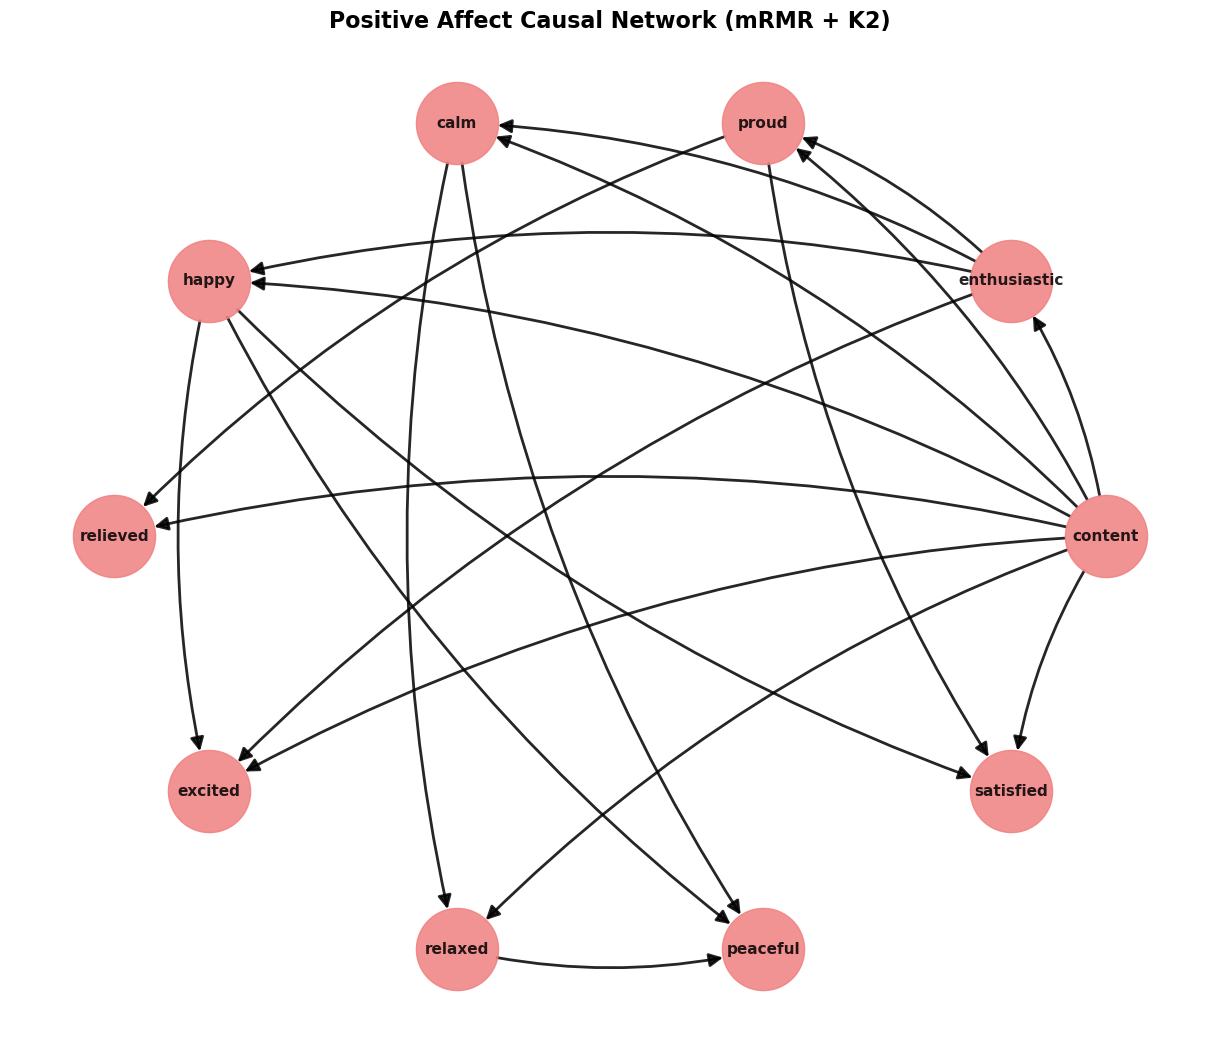

In [12]:
# ---------------------------------------------------------------
# STEP 7 - Visualize the learned causal graph
# ---------------------------------------------------------------

plt.figure(figsize=(12, 10))


pos = nx.circular_layout(G) 
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='#F08080',     
    node_size=3500,
    font_size=11,
    font_weight='bold',
    arrows=True,
    arrowsize=20,
    arrowstyle='-|>',
    edge_color='black',
    width=2,
    alpha=0.85,
    connectionstyle='arc3,rad=0.12',  
    min_source_margin=20,
    min_target_margin=20
)

plt.title(
    "Positive Affect Causal Network (mRMR + K2)",
    fontsize=16,
    fontweight='bold'
)
plt.axis('off')
plt.tight_layout()
plt.show()